# Topology and Stationary Modes

### Required Libraries

In [47]:
import numpy as np       #numpy
import scipy.sparse as sp #sparse matrices
import matplotlib.pyplot as plt #matplot
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from firedrake import *
from netgen.occ import *
from ngsolve.webgui import Draw
import math

### Mesh Generation

In [75]:
def TriAnnulusMesh(R, r, nr, nt, diagonal="crossed", coord_degree=1):
    base = PeriodicRectangleMesh(nt, nr, 2*np.pi, R - r, direction="x",
                                 quadrilateral=False, diagonal=diagonal)
    x, y = SpatialCoordinate(base)
    V = (base.coordinates.function_space() if coord_degree == 1
         else VectorFunctionSpace(base, "DG", coord_degree))
    coord = Function(V).interpolate(as_vector([(r + y)*cos(x), (r + y)*sin(x)]))
    return Mesh(coord)

In [72]:
def make_FEEC_B_N2(mesh, degree):    # full:     CG_{r+1} -> N2curl_r
    return FunctionSpace(mesh, "N2curl", degree) * FunctionSpace(mesh, "CG", degree + 1)

def make_FEEC_B_N1(mesh, degree):    # trimmed:  CG_r -> N1curl_r
    return FunctionSpace(mesh, "N1curl", degree) * FunctionSpace(mesh, "CG", degree)


def cross2d(a, b):
    """z-component of a x b for planar a, b: the 2D proxy of the 3D cross product."""
    return a[0]*b[1] - a[1]*b[0]


def B_formulation(W, u=None, eps=Constant(1.0)):
    (v, p) = TrialFunctions(W)
    (w, q) = TestFunctions(W)

    a = eps * inner(curl(v), curl(w)) * dx
    if u is not None:
        a += inner(cross2d(v, u), curl(w)) * dx        # note the order: v x u
    a += (-inner(grad(p), w) + inner(v, grad(q))) * dx
    m = inner(v, w) * dx

    bc = [DirichletBC(W.sub(0), Constant((0, 0)), "on_boundary"),
          DirichletBC(W.sub(1), 0, "on_boundary")]
    return a, m, bc

def make_eigensolver(a, m, bcs, n_evals, opts):
    prob = LinearEigenproblem(A=a, M=m, bcs=bcs)
    return LinearEigensolver(prob, n_evals=n_evals, solver_parameters=opts)

def eigenvalues(solver, drop_harmonic=True, tol=1e-8):
    nconv = solver.solve()
    eig = [solver.eigenvalue(i) for i in range(nconv)]
    if drop_harmonic:
        # constraint (c): ω ⊥ H^0 ≅ ℝ. The constants span ker(a), so the
        # harmonic mode appears as an exact λ = 0 and is removed here.
        eig = [lam for lam in eig if abs(lam) > tol]
    return eig

    


def plot_spectrum(eigenvalues):
    """
    Plots a list or array of complex eigenvalues in the complex plane.
    """
    # Convert to a numpy array to easily extract real and imaginary parts
    evs = np.array(eigenvalues)
    
    real_parts = evs.real
    imag_parts = evs.imag
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot the eigenvalues as a scatter plot
    ax.scatter(real_parts, imag_parts, color='red', marker='x', s=50, zorder=3)
    
    # Draw solid black lines for the real and imaginary axes (x=0, y=0)
    ax.axhline(0, color='black', linewidth=1, zorder=2)
    ax.axvline(0, color='black', linewidth=1, zorder=2)
    
    # Format the grid and labels
    ax.grid(True, linestyle='--', alpha=0.7, zorder=1)
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')
    ax.set_title('Eigenvalue Spectrum')
    
    # Show the plot
    plt.show()


## Annulus

In [107]:
def get_wind(n, mesh=None, y0=None, L=np.pi):
    """
    W0  (0, 0)                  -- no wind
    W1  (1, 1)                  -- uniform, C^inf
    W3  (sign(y - y0), 0)       -- Heaviside shear, L^inf but not W^{1,inf}
    """
    if n == 0:
        return None
    elif n == 1:
        return as_vector([Constant(1.0), Constant(1.0)])
    elif n == 2:
        x, y = SpatialCoordinate(mesh)
        # FIX: Replaced math.sin with UFL's sin
        return as_vector([sin(y), sin(x)])
        
    elif n == 3:                                     # W3 in the table
        x, y = SpatialCoordinate(mesh)
        y0 = Constant(L / 2) if y0 is None else Constant(y0)
        return as_vector([conditional(gt(y, y0), 1.0, -1.0), Constant(0.0)])

    elif n == 4:
        x, y = SpatialCoordinate(mesh)
        # Calculate radial distance in Cartesian coordinates
        r = sqrt(x**2 + y**2)
        
        # 1. Use abs() to prevent negative numbers
        # 2. Add a tiny epsilon to prevent exact division by zero
        eps = Constant(1e-6) 
        
        # Apply the scalar multiplier to the (-y, x) vector
        return (1.0 / (abs(r - 1.5) + eps)**1.5) * as_vector([-y, x])


mesh_annulus = TriAnnulusMesh(R=2.0, r=1.0, nr=10, nt=32)

# from firedrake import *
# from firedrake.pyplot import quiver, triplot
# import matplotlib.pyplot as plt

# # 1. Get your UFL expression from your function
# wind_expr = get_wind(n=4, mesh=mesh_annulus,y0=1)

# # 2. Create a VectorFunctionSpace on your mesh
# V = VectorFunctionSpace(mesh_annulus, "CG", 1)

# # 3. Project the expression into the function space
# wind_func = project(wind_expr, V)

# # 4. Plot it
# fig, ax = plt.subplots(figsize=(8, 8))

# # Plot the mesh (without the unsupported kwargs)
# #triplot(mesh_annulus, axes=ax)

# # Plot the vector field using quiver
# quiver(wind_func, axes=ax)

# ax.set_aspect('equal')
# ax.set_title("Wind Profile n=2 on TriAnnulusMesh")
# plt.show()

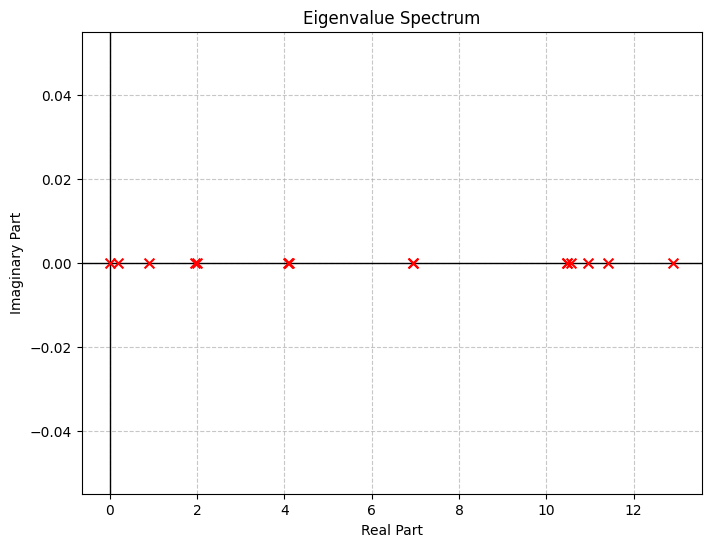

[(0.9104665447825534+0j), (0.20061623888495939+0j), (-3.419486915845482e-14+0j), (1.9555564559507759+0j), (1.9945793855164025+0j), (4.08164086306876+0j), (4.1119004509879025+0j), (6.955030328956003+0j), (6.955041251309879+0j), (10.477458201493683+0j), (10.48329757715745+0j), (10.572758472834721+0j), (10.951288623421735+0j), (11.417295954251141+0j), (12.908312025605543+0j)]


In [108]:
#### FEEC Conforming
opts = {
    "eps_gen_non_hermitian": None,
    # Shift slightly off 1.0 to prevent the matrix from becoming perfectly singular
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    # THE FIX: Increase the MUMPS workspace allocation by 500%
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}

W = make_FEEC_B_N2( mesh_annulus,1)
u = get_wind(2, mesh=mesh_annulus, y0=None, L=0)
a,m,bc = B_formulation(W, u, eps=Constant(1))
solver = make_eigensolver(a,m,bc,10,opts)
eig = eigenvalues(solver, drop_harmonic=False)
plot_spectrum(eig)
print(eig)

In [69]:
#### FEEC Non-Conforming
opts = {
    "eps_gen_non_hermitian": None,
    # Shift slightly off 1.0 to prevent the matrix from becoming perfectly singular
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    # THE FIX: Increase the MUMPS workspace allocation by 500%
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}
W = make_nodal(1, mesh)
a,m,bc = B_formulation(W)
solver = solve(a,m,bc,10,opts)
eig = eigenvalues(solver, drop_harmonic=False)
print(eig)

NameError: name 'make_nodal' is not defined

### 0 Velocity Field / Annulus

In [50]:
from firedrake.mesh import plex_from_cell_list

def SolidTorusTetMesh(R, r, nR=16, cross_section=None, refinement_level=1,
                      comm=COMM_WORLD, name="solid_torus"):
    """Structured tetrahedral solid torus (axis = z).

    Sweeps a triangular disk cross-section around the z-axis in nR steps and
    splits each prism into 3 tets by the Freudenthal rule, so the diagonals
    agree across shared quad faces.
    """
    if nR < 3:
        raise ValueError("nR must be at least 3")

    # cross-section, built serially so every rank holds the whole thing
    if cross_section is None:
        cross_section = UnitDiskMesh(refinement_level=refinement_level, comm=COMM_SELF)
    xy = cross_section.coordinates.dat.data_ro_with_halos
    tri = np.sort(cross_section.coordinates.cell_node_map().values, axis=1)

    rho = R + r * xy[:, 0]          # cross-section centred at (rho, z) = (R, 0)
    zed = r * xy[:, 1]
    nv = rho.size

    th = 2.0 * np.pi * np.arange(nR) / nR       # layer nR identified with layer 0
    coords = np.column_stack([np.outer(np.cos(th), rho).ravel(),
                              np.outer(np.sin(th), rho).ravel(),
                              np.tile(zed, nR)])

    cells = []
    for k in range(nR):
        a = k * nv + tri                        # bottom of prism layer k
        b = ((k + 1) % nR) * nv + tri           # top
        cells += [np.column_stack([a[:, 0], a[:, 1], a[:, 2], b[:, 2]]),
                  np.column_stack([a[:, 0], a[:, 1], b[:, 1], b[:, 2]]),
                  np.column_stack([a[:, 0], b[:, 0], b[:, 1], b[:, 2]])]

    plex = plex_from_cell_list(3, np.vstack(cells), coords, comm)
    plex.createLabel("Face Sets")
    plex.markBoundaryFaces("Face Sets", 1)
    return Mesh(plex, name=name)

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?


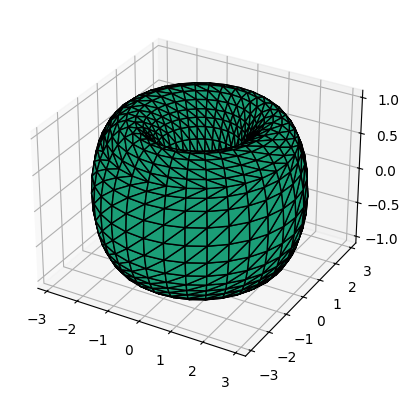

In [53]:
mesh_torus = SolidTorusTetMesh(R=2.0, r=1.0, nR=32, refinement_level=2)
triplot(mesh_torus)

In [54]:
#### FEEC Conforming
opts = {
    "eps_gen_non_hermitian": None,
    # Shift slightly off 1.0 to prevent the matrix from becoming perfectly singular
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    # THE FIX: Increase the MUMPS workspace allocation by 500%
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}
W = make_FEEC_B_N2(1, mesh_torus)
a,m,bc = B_formulation(W)
solver = solve(a,m,bc,10,opts)
eig = eigenvalues(solver, drop_harmonic=False)
plot_spectrum(eig)

RuntimeError: Provided boundary value [0. 0.] does not match shape of space